In [ ]:
import pandas as pd

df = pd.read_csv("AQI.csv")
df.head()

,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,India,Andhra_Pradesh,Vijayawada,"Rajiv Nagar, Vijayawada - APPCB",19-05-2025 10:00,16.554731,80.649110,SO2,20.0,23.0,21.0
1,India,Andhra_Pradesh,Vijayawada,"Rajiv Nagar, Vijayawada - APPCB",19-05-2025 10:00,16.554731,80.649110,OZONE,17.0,35.0,22.0
2,India,Andhra_Pradesh,Visakhapatnam,"GVM Corporation, Visakhapatnam - APPCB",19-05-2025 10:00,17.720000,83.300000,PM10,23.0,66.0,36.0
3,India,Arunachal_Pradesh,Naharlagun,"Naharlagun, Naharlagun - APSPCB",19-05-2025 10:00,27.103358,93.679645,NO2,4.0,5.0,5.0
4,India,Arunachal_Pradesh,Naharlagun,"Naharlagun, Naharlagun - APSPCB",19-05-2025 10:00,27.103358,93.679645,CO,10.0,19.0,12.0


In [ ]:
df.isnull().sum()

,0
country,0
state,0
city,0
station,0
last_update,0
latitude,0
longitude,0
pollutant_id,0
pollutant_min,299
pollutant_max,299


In [ ]:
df = df.fillna(df.mean(numeric_only=True))
df.isnull().sum()

,0
country,0
state,0
city,0
station,0
last_update,0
latitude,0
longitude,0
pollutant_id,0
pollutant_min,0
pollutant_max,0


In [ ]:
df.mean(numeric_only=True)

,0
latitude,22.250067
longitude,78.682006
pollutant_min,21.670986
pollutant_max,59.251620
pollutant_avg,33.933765


In [ ]:
df.median(numeric_only=True)

,0
latitude,23.023389
longitude,77.508730
pollutant_min,16.000000
pollutant_max,46.000000
pollutant_avg,27.000000


In [ ]:
df.mode(numeric_only=True)

,latitude,longitude,pollutant_min,pollutant_max,pollutant_avg
0,8.514909,70.909168,21.670986,59.25162,33.933765
1,8.563700,71.393989,NaN,NaN,NaN
2,8.728442,72.456691,NaN,NaN,NaN
3,8.878700,72.515201,NaN,NaN,NaN
4,9.363990,72.553024,NaN,NaN,NaN
...,...,...,...,...,...
359,30.735567,91.700464,NaN,NaN,NaN
360,30.736056,91.874880,NaN,NaN,NaN
361,30.943887,92.734055,NaN,NaN,NaN
362,31.321907,92.795250,NaN,NaN,NaN


In [ ]:
df.std(numeric_only=True)

,0
latitude,5.519664
longitude,4.854371
pollutant_min,24.262672
pollutant_max,62.611962
pollutant_avg,34.324902


In [ ]:
df.var(numeric_only=True)

,0
latitude,30.466693
longitude,23.564921
pollutant_min,588.677270
pollutant_max,3920.257841
pollutant_avg,1178.198899


In [ ]:
correlation = df.corr(numeric_only=True)
correlation

,latitude,longitude,pollutant_min,pollutant_max,pollutant_avg
latitude,1.000000,0.117604,0.201813,0.245437,0.233650
longitude,0.117604,1.000000,-0.075898,-0.061925,-0.070451
pollutant_min,0.201813,-0.075898,1.000000,0.679579,0.914410
pollutant_max,0.245437,-0.061925,0.679579,1.000000,0.831986
pollutant_avg,0.233650,-0.070451,0.914410,0.831986,1.000000


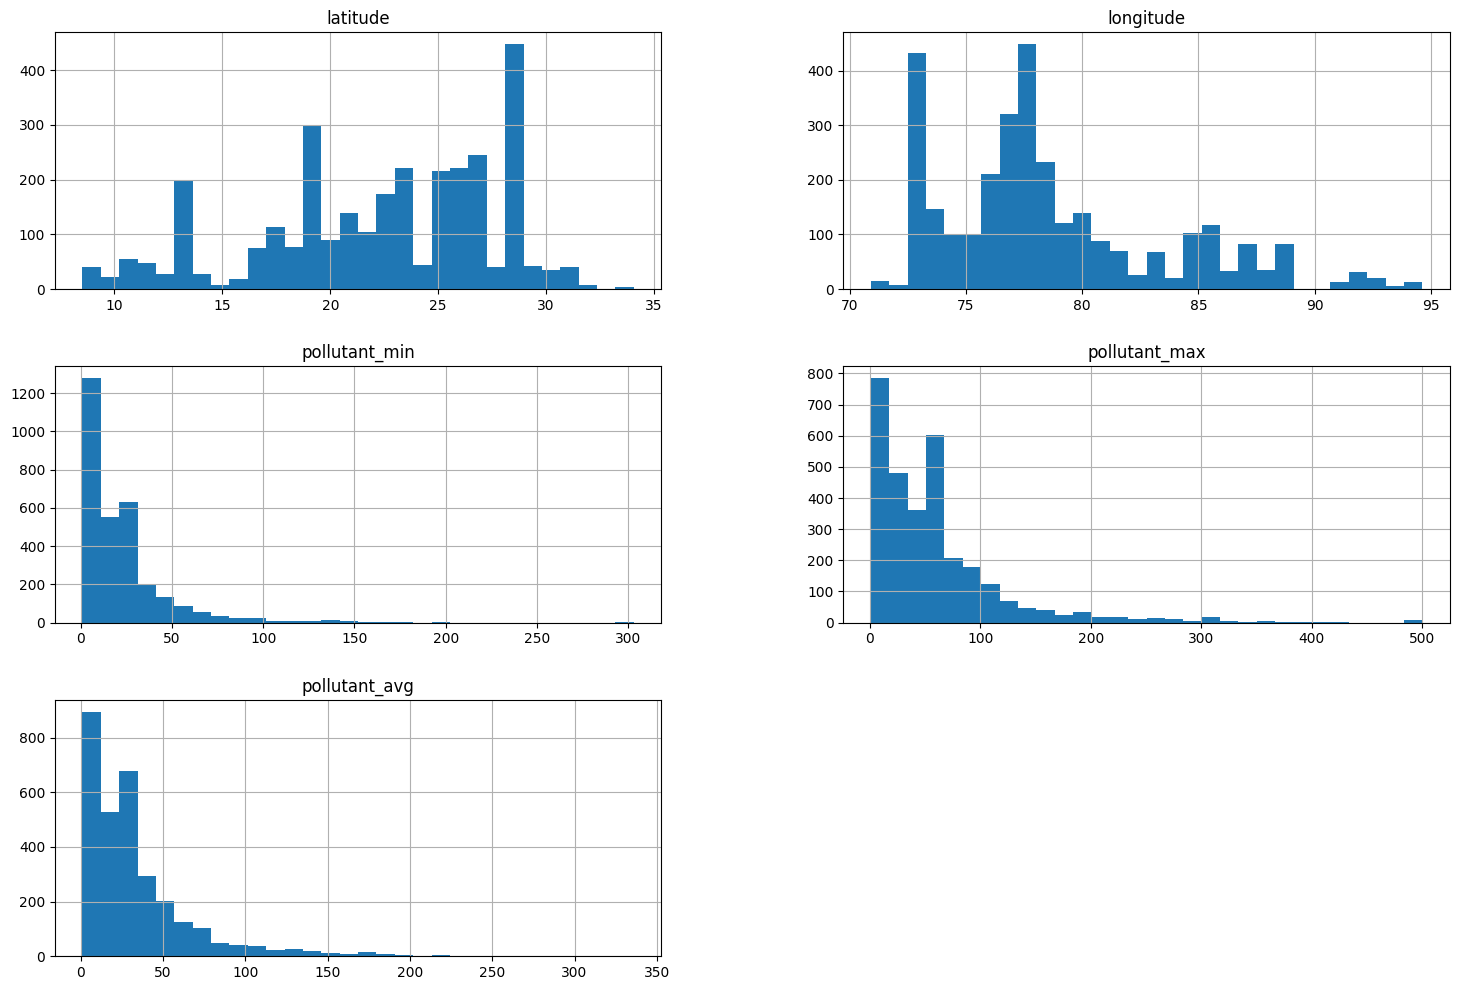

In [ ]:
import matplotlib.pyplot as plt

df.hist(figsize=(18,12), bins=30)

plt.show()

In [ ]:
df.corr(numeric_only=True)['pollutant_avg'].sort_values(ascending=False)

,pollutant_avg
pollutant_avg,1.000000
pollutant_min,0.914410
pollutant_max,0.831986
latitude,0.233650
longitude,-0.070451


In [ ]:
df.cov(numeric_only=True)

,latitude,longitude,pollutant_min,pollutant_max,pollutant_avg
latitude,30.466693,3.151150,27.027145,84.822162,44.267870
longitude,3.151150,23.564921,-8.939227,-18.821583,-11.739031
pollutant_min,27.027145,-8.939227,588.677270,1032.370605,761.533310
pollutant_max,84.822162,-18.821583,1032.370605,3920.257841,1788.061540
pollutant_avg,44.267870,-11.739031,761.533310,1788.061540,1178.198899


In [ ]:
df.describe()

,latitude,longitude,pollutant_min,pollutant_max,pollutant_avg
count,3077.000000,3077.000000,3077.000000,3077.000000,3077.000000
mean,22.250067,78.682006,21.670986,59.251620,33.933765
std,5.519664,4.854371,24.262672,62.611962,34.324902
min,8.514909,70.909168,1.000000,1.000000,1.000000
25%,19.036458,75.521300,6.000000,17.000000,10.000000
50%,23.023389,77.508730,16.000000,46.000000,27.000000
75%,26.833997,80.723178,26.000000,74.000000,42.000000
max,34.066206,94.636574,303.000000,500.000000,336.000000


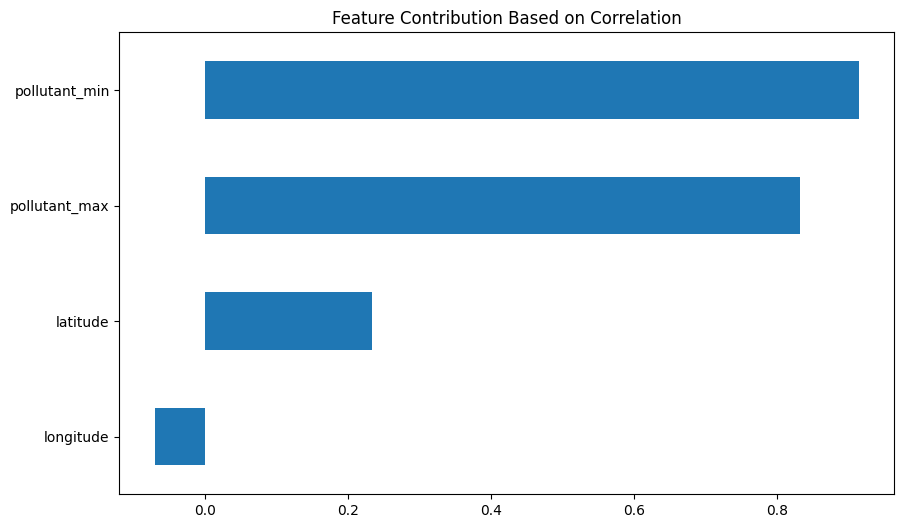

In [ ]:
import matplotlib.pyplot as plt

corr_target = df.corr(numeric_only=True)['pollutant_avg'].drop('pollutant_avg')

corr_target.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title("Feature Contribution Based on Correlation")

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('pollutant_avg', axis=1)
y = df['pollutant_avg']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

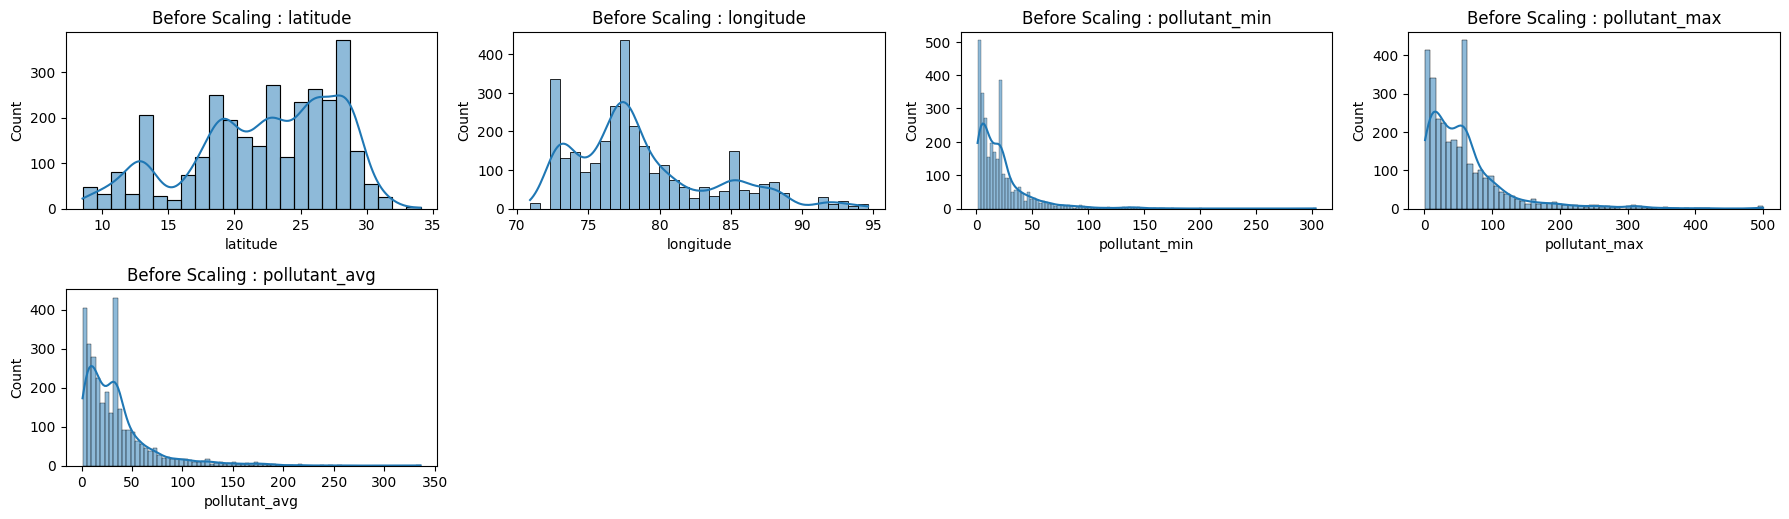

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(18,10))
for i, col in enumerate(numeric_cols):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f"Before Scaling : {col}")

plt.tight_layout()
plt.show()

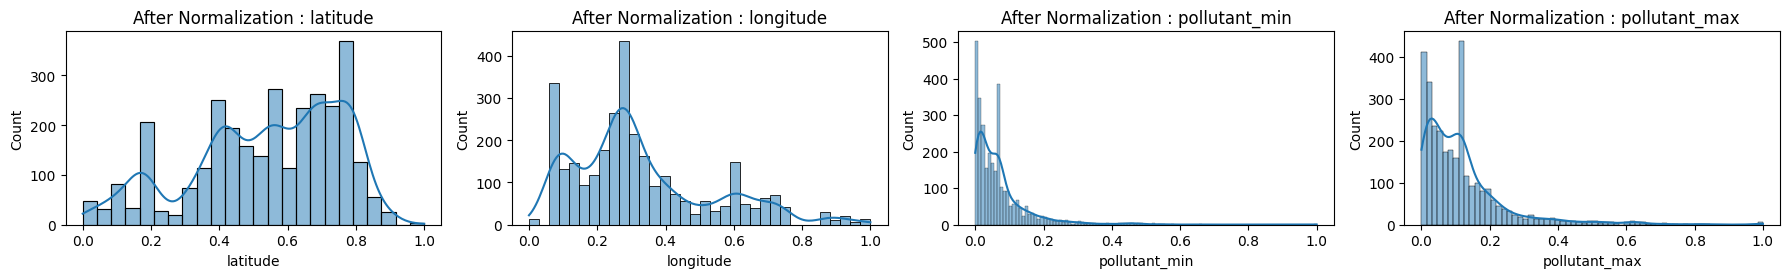

In [ ]:
from sklearn.preprocessing import MinMaxScaler
X_numeric = X.select_dtypes(include=['int64','float64'])

scaler = MinMaxScaler()
X_norm = pd.DataFrame(scaler.fit_transform(X_numeric), columns=X_numeric.columns)
plt.figure(figsize=(18,10))
for i, col in enumerate(X_norm.columns):
    plt.subplot(4,4,i+1)
    sns.histplot(X_norm[col], kde=True)
    plt.title(f"After Normalization : {col}")

plt.tight_layout()
plt.show()

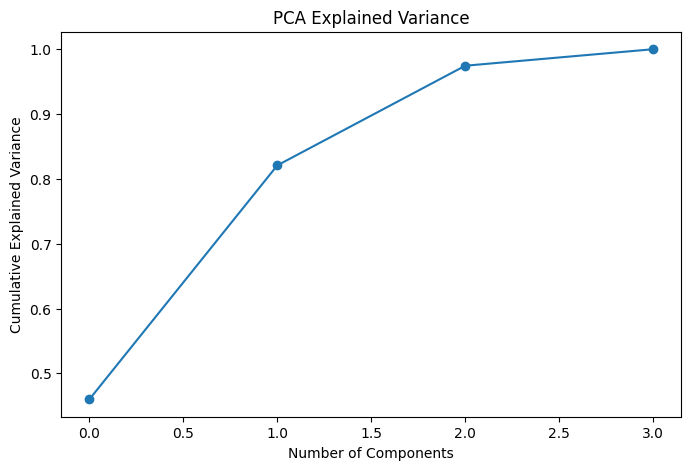

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA()
pca.fit(X_norm)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    np.cumsum(pca.explained_variance_ratio_),
    marker='o'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.show()

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

pca_95 = PCA(n_components=0.95)

X_reduced = pca_95.fit_transform(X_norm)
print("Original shape:", X_norm.shape)
print("Reduced shape :", X_reduced.shape)
print("No. of components selected:", pca_95.n_components_)

Original shape: (3077, 4)
Reduced shape : (3077, 3)
No. of components selected: 3


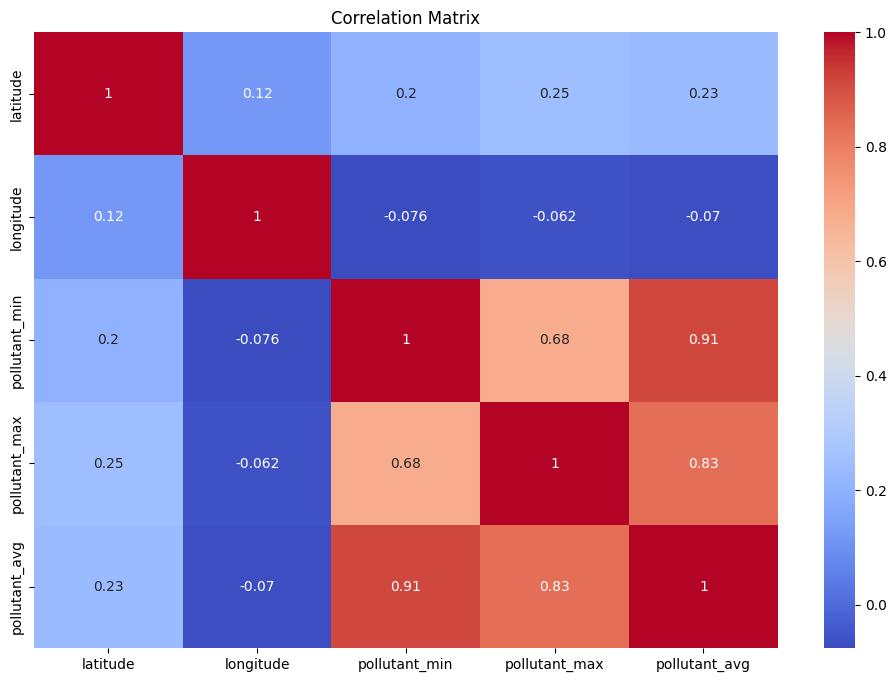

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
X_train_num = X_train.select_dtypes(include=['int64','float64'])
X_test_num = X_test.select_dtypes(include=['int64','float64'])

lr = LinearRegression()

lr.fit(X_train_num, y_train)

y_pred_lr = lr.predict(X_test_num)

print("Linear Regression R2:", r2_score(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))

Linear Regression R2: 0.9088598351192535
MSE: 116.31483765851594


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
y_class = (y > y.mean()).astype(int)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_numeric, y_class,
    test_size=0.2,
    random_state=42
)
log_model = LogisticRegression()

log_model.fit(X_train_c, y_train_c)

y_pred_log = log_model.predict(X_test_c)

print("Logistic Accuracy:", accuracy_score(y_test_c, y_pred_log))

Logistic Accuracy: 0.926948051948052


Accuracy (R2): 0.9088598351192535
MSE: 116.31483765851594


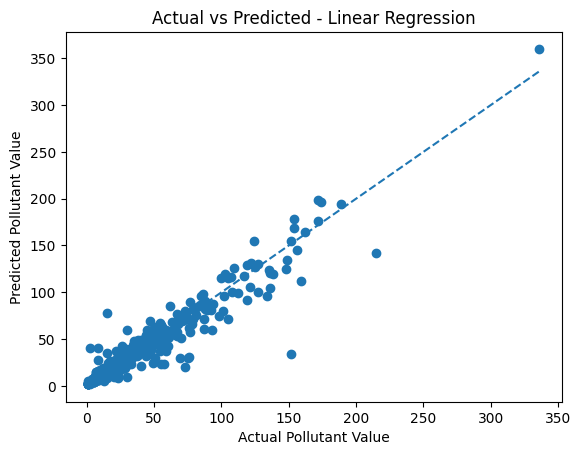

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
y_pred_lr = lr.predict(X_test_num)
r2 = r2_score(y_test, y_pred_lr)
print("Accuracy (R2):", r2)
print("MSE:", mean_squared_error(y_test, y_pred_lr))
plt.figure()
plt.scatter(y_test, y_pred_lr)

plt.xlabel("Actual Pollutant Value")
plt.ylabel("Predicted Pollutant Value")
plt.title("Actual vs Predicted - Linear Regression")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.show()

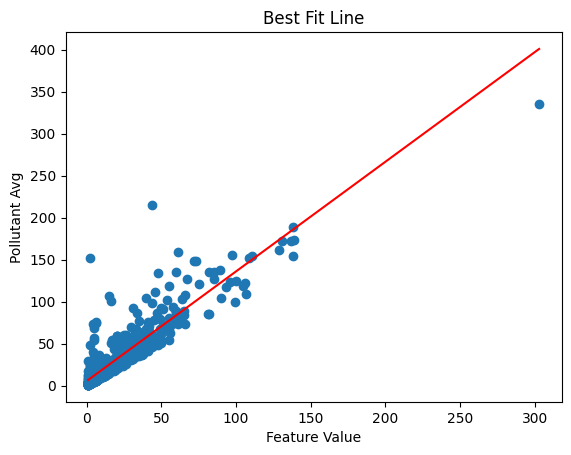

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

# Take one feature only
X_train_1d = X_train_num[['pollutant_min']]
X_test_1d = X_test_num[['pollutant_min']]

# Train model
model = LinearRegression()
model.fit(X_train_1d, y_train)

# Predict
y_pred_1d = model.predict(X_test_1d)

# Sort values
sorted_idx = np.argsort(X_test_1d.iloc[:,0])

X_sorted = X_test_1d.iloc[:,0].iloc[sorted_idx]
y_sorted = y_pred_1d[sorted_idx]

# Plot
plt.figure()
plt.scatter(X_test_1d, y_test)

plt.plot(X_sorted, y_sorted, color='red')

plt.xlabel("Feature Value")
plt.ylabel("Pollutant Avg")
plt.title("Best Fit Line")

plt.show()

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred_lr = lr.predict(X_test_num)

print("Linear Regression R2:", r2_score(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))

Linear Regression R2: 0.9088598351192535
MSE: 116.31483765851594


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Use only numeric data
X_train_num = X_train.select_dtypes(include=['int64','float64'])
X_test_num = X_test.select_dtypes(include=['int64','float64'])

rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)

rf.fit(X_train_num, y_train)

y_pred_rf = rf.predict(X_test_num)

rf_score = r2_score(y_test, y_pred_rf)
lr_score = r2_score(y_test, y_pred_lr)

print("Linear Regression R2:", lr_score)
print("Random Forest R2:", rf_score)

Linear Regression R2: 0.9088598351192535
Random Forest R2: 0.9024420594117266


In [ ]:
# Use only numeric columns
X_numeric = df.select_dtypes(include=['int64','float64']).drop('pollutant_avg', axis=1)

# Predict
df['Predicted_Pollutant'] = lr.predict(X_numeric)

# Save file
df.to_csv("aqi_prediction_output.csv", index=False)

In [ ]:
from google.colab import files
files.download("aqi_prediction_output.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>